**I am to predict the churn from the data**

Churn rate is a measure of the number of customers or employees who leave a company during a given period. It can also refer to the amount of revenue lost as a result of the departures. Changes in a business's churn rate can provide valuable insight into an organization.

Don’t forget that you need to first do the analysis to understand the data before modeling


In [1]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
%matplotlib inline

In [2]:
pwd # check current working directory

'c:\\Users\\djima\\OneDrive\\Desktop\\AI_NOW_ML\\PROJECT_1'

In [3]:
# let's load our data
df = pd.read_csv('PROJECT_2_Churn_data.csv')

In [4]:
df.head(5) # Displaying the first 5 roles of the dataset

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.tail(5) # Displaying the last 5 roles of the dataset 

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [6]:
# let's rename the 'Promoted_or_Not' as output to Target
df.rename(columns={'Churn': 'Target'}, inplace=True)

In [7]:
# random peeeking at the data
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Target
8012,8013,15702715,Kao,747,France,Female,34,10,0.00,2,1,1,50759.80,0
3226,3227,15796351,Yao,603,Germany,Male,35,1,105346.03,2,1,1,130379.50,0
3903,3904,15678129,Hill,643,Spain,Female,45,9,150840.03,2,1,0,155516.35,0
9709,9710,15682839,Genovesi,575,France,Female,57,8,137936.94,1,1,1,84475.13,0
4112,4113,15763107,Little,700,France,Female,30,9,0.00,1,1,1,174971.64,0
1779,1780,15673342,K'ung,703,France,Male,36,2,0.00,2,1,0,108790.95,0
292,293,15655774,Booth,583,France,Male,27,7,0.00,2,1,0,51285.49,0
1459,1460,15571778,Trentini,817,France,Female,55,10,117561.49,1,1,0,95941.55,1
2268,2269,15777553,Hanson,659,France,Female,56,9,123785.24,1,1,0,99504.03,1
9479,9480,15596212,Yang,781,Spain,Male,35,1,0.00,2,0,0,42117.90,0


In [8]:
df.describe #this gives the summary of our DataFrame’s columns together with the labels

<bound method NDFrame.describe of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumO

In [9]:
df.describe() # here is the statistical summary of only the numerical features of the data

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Target
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
df.describe(include='all').T # this is the description of all the features

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [11]:
# Check data size
#this data contains 38312 samples/rows and 19 features/columns including the Target(Output)
df.shape 

(10000, 14)

In [12]:
#Getting the vital statistcs of the data
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Target           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
df # the complete data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Target
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [14]:
# let's check for duplicate values if any
df.duplicated().sum() # there is no duplicate

np.int64(0)

In [15]:
df.nunique() # checking out the columns in our dataset

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Target                 2
dtype: int64

In [16]:
df.RowNumber.unique() # checking unique values in Qualification column

array([    1,     2,     3, ...,  9998,  9999, 10000])

In [17]:
df.CustomerId.unique() # checking unique values in Qualification column

array([15634602, 15647311, 15619304, ..., 15584532, 15682355, 15628319])

In [18]:
df.Surname.unique() # checking unique values in Qualification column

array(['Hargrave', 'Hill', 'Onio', ..., 'Kashiwagi', 'Aldridge',
       'Burbidge'], dtype=object)

In [19]:
df.CreditScore.unique() # checking unique values in Qualification column

array([619, 608, 502, 699, 850, 645, 822, 376, 501, 684, 528, 497, 476,
       549, 635, 616, 653, 587, 726, 732, 636, 510, 669, 846, 577, 756,
       571, 574, 411, 591, 533, 553, 520, 722, 475, 490, 804, 582, 472,
       465, 556, 834, 660, 776, 829, 637, 550, 698, 585, 788, 655, 601,
       656, 725, 511, 614, 742, 687, 555, 603, 751, 581, 735, 661, 675,
       738, 813, 657, 604, 519, 664, 678, 757, 416, 665, 777, 543, 506,
       493, 652, 750, 729, 646, 647, 808, 524, 769, 730, 515, 773, 814,
       710, 413, 623, 670, 622, 785, 605, 479, 685, 538, 562, 721, 628,
       668, 828, 674, 625, 432, 770, 758, 795, 686, 789, 589, 461, 584,
       579, 663, 682, 793, 691, 485, 650, 754, 535, 716, 539, 706, 586,
       631, 717, 800, 683, 704, 615, 667, 484, 480, 578, 512, 606, 597,
       778, 514, 525, 715, 580, 807, 521, 759, 516, 711, 618, 643, 671,
       689, 620, 676, 572, 695, 592, 567, 694, 547, 594, 673, 610, 767,
       763, 712, 703, 662, 659, 523, 772, 545, 634, 739, 771, 68

In [20]:
df.Geography.unique() # checking unique values in Qualification column

array(['France', 'Spain', 'Germany'], dtype=object)

In [21]:
df.Gender.unique() # checking unique values in Qualification column

array(['Female', 'Male'], dtype=object)

In [22]:
df.Age.unique() # checking unique values in Qualification column

array([42, 41, 39, 43, 44, 50, 29, 27, 31, 24, 34, 25, 35, 45, 58, 32, 38,
       46, 36, 33, 40, 51, 61, 49, 37, 19, 66, 56, 26, 21, 55, 75, 22, 30,
       28, 65, 48, 52, 57, 73, 47, 54, 72, 20, 67, 79, 62, 53, 80, 59, 68,
       23, 60, 70, 63, 64, 18, 82, 69, 74, 71, 76, 77, 88, 85, 84, 78, 81,
       92, 83])

In [23]:
df.Tenure.unique() # checking unique values in Qualification column

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [24]:
df.Balance.unique() # checking unique values in Qualification column

array([     0.  ,  83807.86, 159660.8 , ...,  57369.61,  75075.31,
       130142.79])

In [25]:
df.NumOfProducts.unique() # checking unique values in Qualification column

array([1, 3, 2, 4])

In [26]:
df.HasCrCard.unique() # checking unique values in Qualification column

array([1, 0])

In [27]:
df.IsActiveMember.unique() # checking unique values in Qualification column

array([1, 0])

In [28]:
df.EstimatedSalary.unique() # checking unique values in Qualification column

array([101348.88, 112542.58, 113931.57, ...,  42085.58,  92888.52,
        38190.78])

In [29]:
df.Target.unique() # checking unique values in Qualification column

array([1, 0])

In [30]:
df.nunique() # checking out the columns in our dataset

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Target                 2
dtype: int64

In [31]:
df.drop(columns=['RowNumber'], inplace=True) # dropping RowNumber column as it is not useful for our analysis
df.drop(columns=['CustomerId'], inplace=True) # dropping CustomerId column as it is not useful for our analysis
df.drop(columns=['Surname'], inplace=True) # dropping Surname column as it is not useful for our analysis

In [32]:
df.duplicated().sum() # checking for duplicate values again after dropping RowNumber column, CustomerId column, and Surname column

np.int64(0)

In [33]:
df.shape  # checking the shape of the data again after dropping RowNumber column and CustomerId column

(10000, 11)

TREATING MISSING VALUES

In [34]:
df.isnull().sum() # there is no missing values in the data

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Target             0
dtype: int64

**DATA PREPARATION**


========== GEOGRAPHY ==========
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Value Counts (Normalized):
Geography
France     0.5014
Germany    0.2509
Spain      0.2477
Name: proportion, dtype: float64


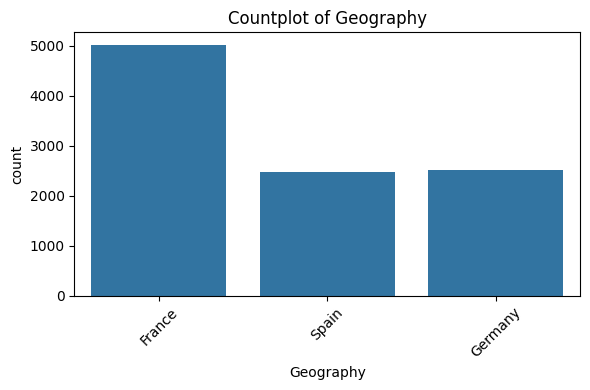


========== GENDER ==========
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Value Counts (Normalized):
Gender
Male      0.5457
Female    0.4543
Name: proportion, dtype: float64


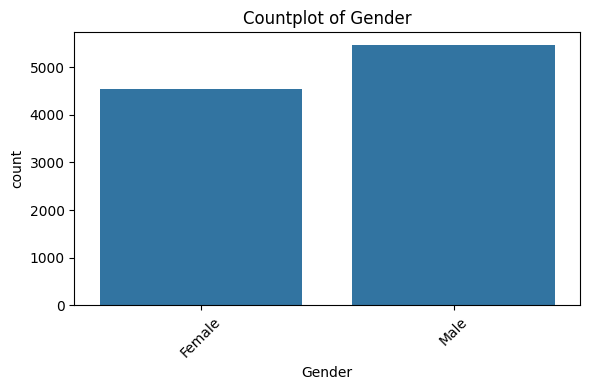

In [35]:
# let's do univariate analysis for both categorical and numerical


# Univariate analysis for categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n========== {col.upper()} ==========")
    print(df[col].value_counts())
    print("\nValue Counts (Normalized):")
    print(df[col].value_counts(normalize=True))
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


========== CREDITSCORE ==========
count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64


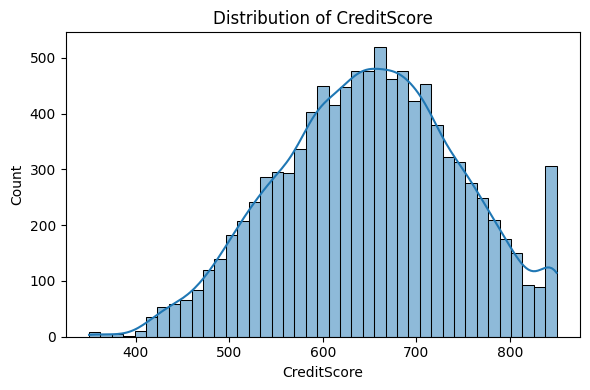


========== AGE ==========
count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64


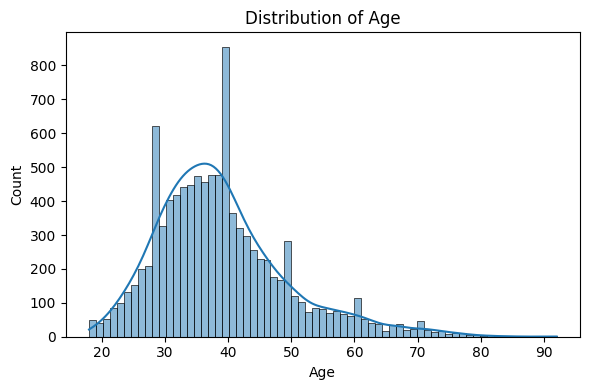


========== TENURE ==========
count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64


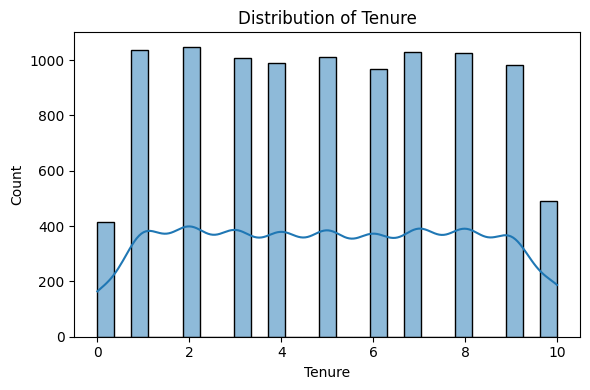


========== BALANCE ==========
count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64


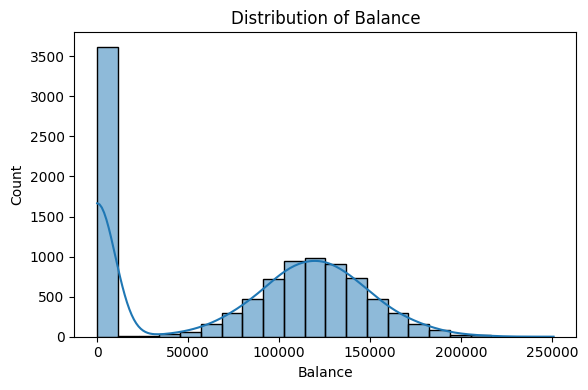


========== NUMOFPRODUCTS ==========
count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumOfProducts, dtype: float64


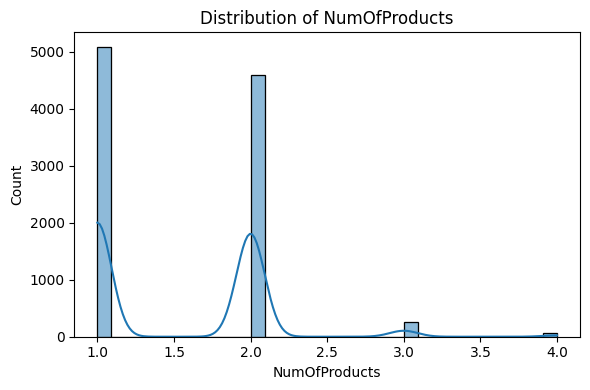


========== HASCRCARD ==========
count    10000.00000
mean         0.70550
std          0.45584
min          0.00000
25%          0.00000
50%          1.00000
75%          1.00000
max          1.00000
Name: HasCrCard, dtype: float64


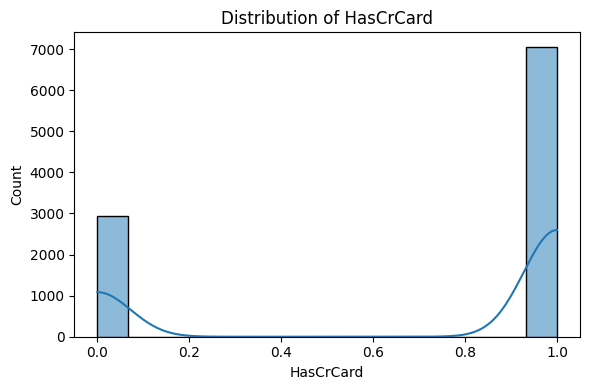


========== ISACTIVEMEMBER ==========
count    10000.000000
mean         0.515100
std          0.499797
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: IsActiveMember, dtype: float64


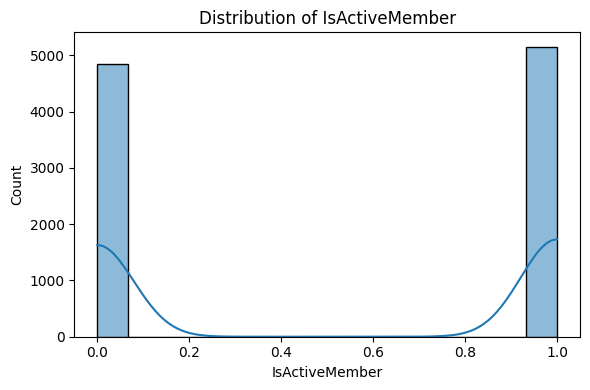


========== ESTIMATEDSALARY ==========
count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64


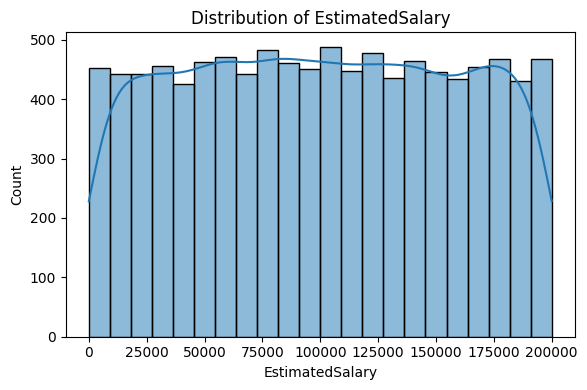


========== TARGET ==========
count    10000.000000
mean         0.203700
std          0.402769
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Target, dtype: float64


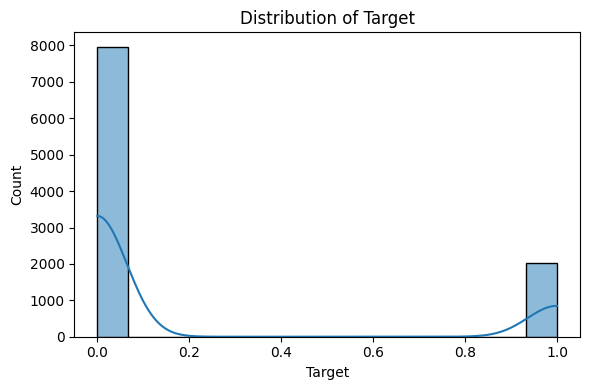

In [36]:
# For numerical 
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    print(f"\n========== {col.upper()} ==========")
    print(df[col].describe())  # Summary statistics

    # Histogram
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

**CORRELATION ANALYSIS**

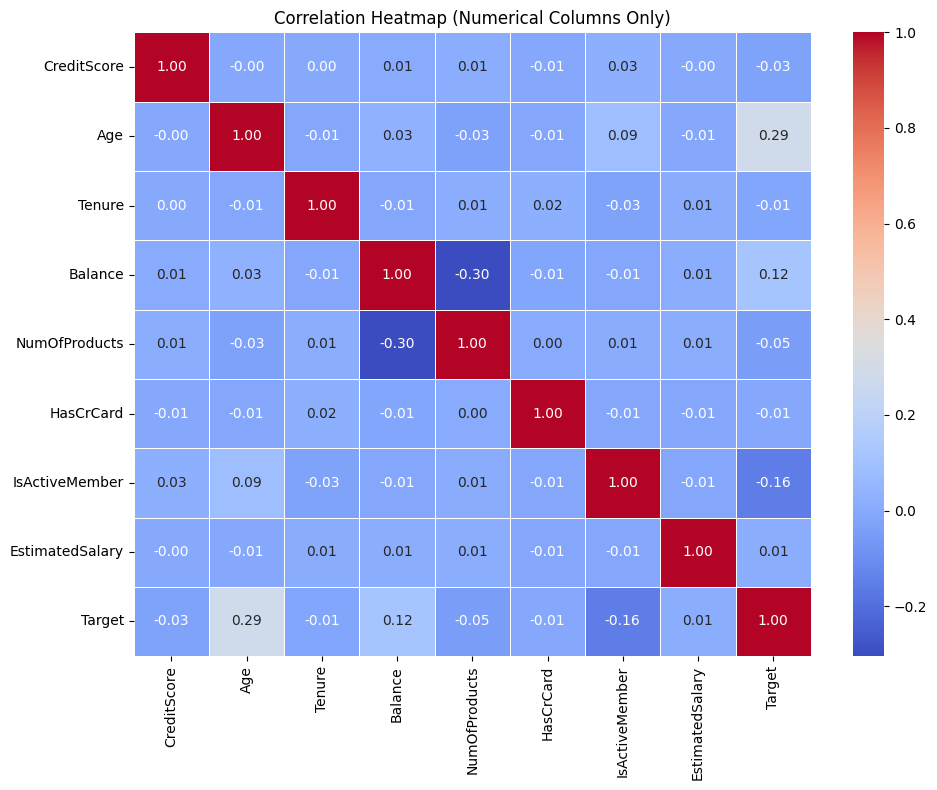


=========== CORRELATION WITH TARGET ===========
Target             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Target, dtype: float64


In [37]:
# Compute correlation matrix
# Select numerical columns from df
num_df = df.select_dtypes(include=['int64', 'float64'])


corr = df[num_df.columns].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (Numerical Columns Only)")
plt.tight_layout()
plt.show()

# Correlation with target (if target exists)
if 'Target' in num_df.columns:
    print("\n=========== CORRELATION WITH TARGET ===========")
    print(corr['Target'].sort_values(ascending=False))
else:
    print("\n⚠ 'Target' column not found among numerical columns.")

In [38]:
df[num_df.columns].corr() # correlation matrix

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Target
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Target,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [39]:
df.duplicated().sum() # checking for duplicate values again after dropping RowNumber column

np.int64(0)

In [40]:
# Outlier detection using Boxplot
y = df['Target']          # target variable
X_1 = df.drop('Target', axis=1)   # all independent features

num_cols = X_1.select_dtypes(include=['int64','float64']).columns # selection of numerical from the data for outliers

In [41]:
X_1.shape # shape of independent features

(10000, 10)

In [42]:
y.shape # shape of dependent feature(Target)

(10000,)

**OUTLIERS**

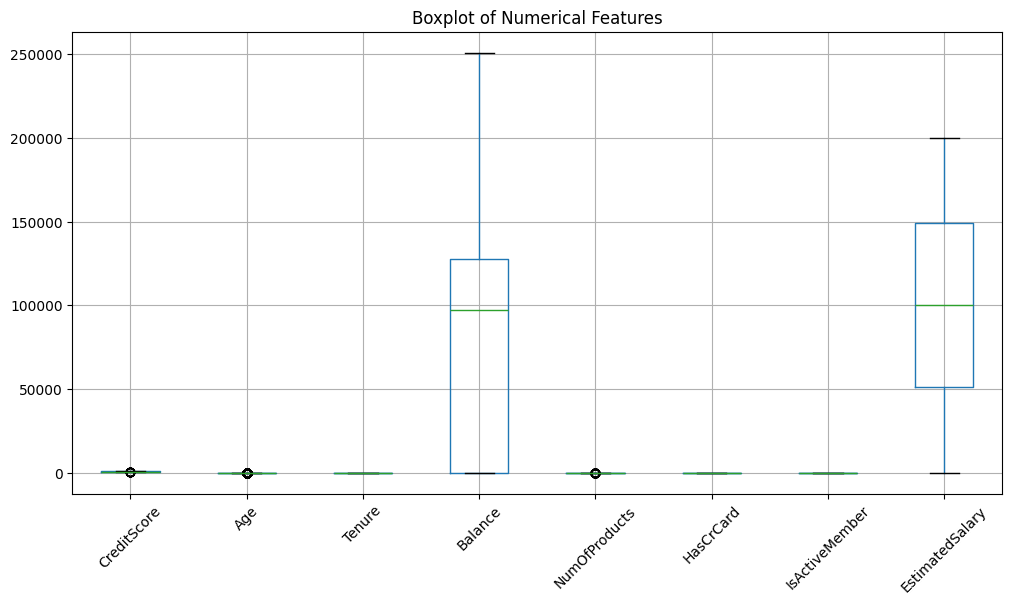

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
X_1[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

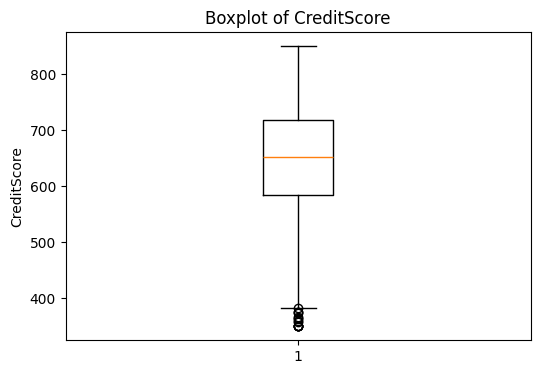

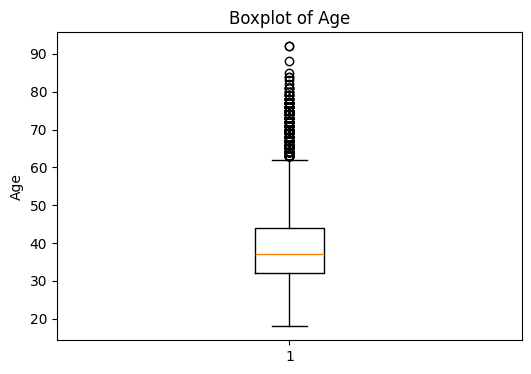

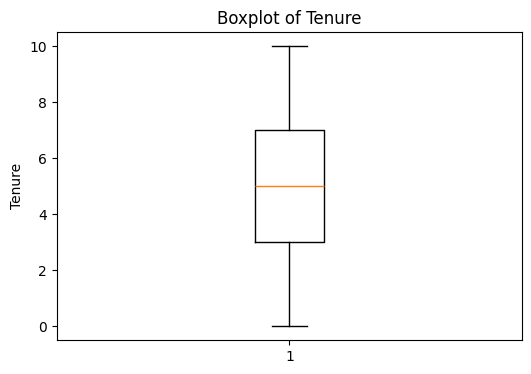

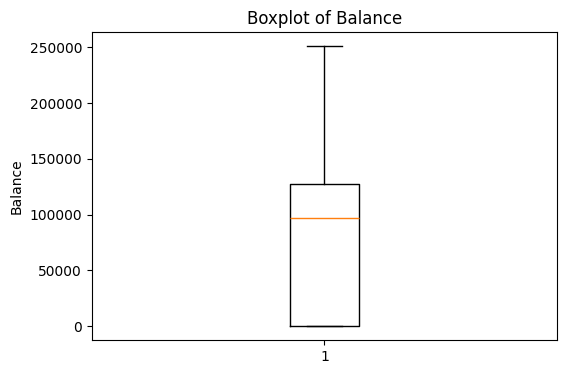

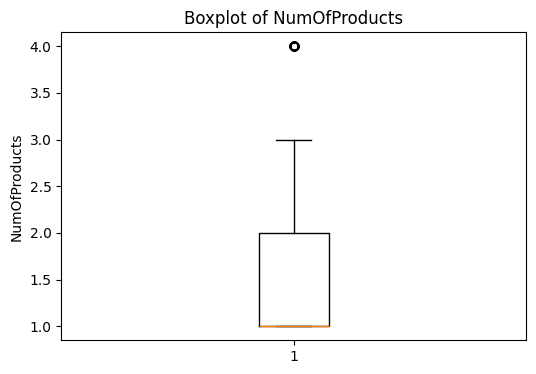

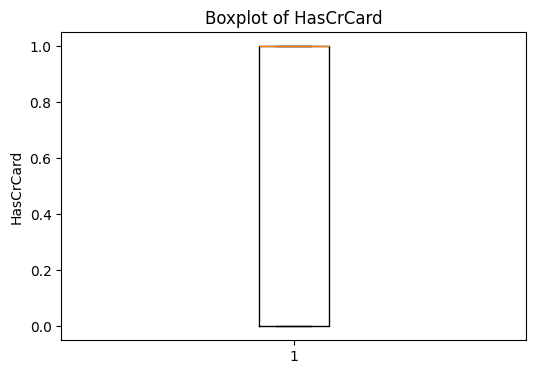

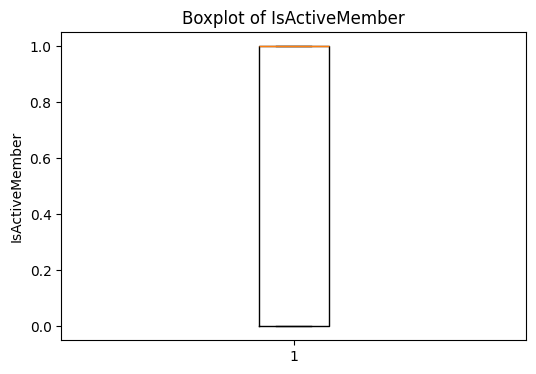

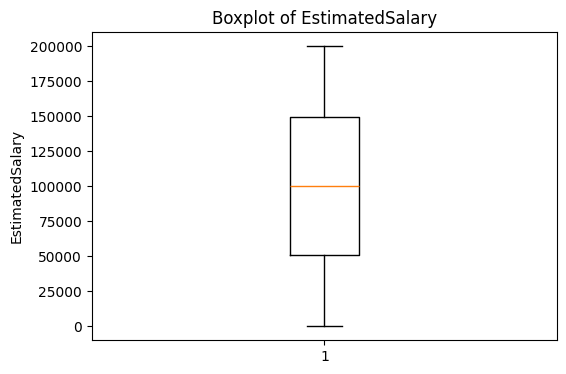

In [44]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(X_1[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [45]:
#num_cols = X.select_dtypes(include=['int64', 'float64']).columns
num_cols = X_1.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = X_1[col].quantile(0.25)
    Q3 = X_1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Winsorization (cap values to bounds)
    X_1[col] = X_1[col].clip(lower=lower_bound, upper=upper_bound) # applying winsorization to the numerical columns

In [46]:
print(X_1.shape) # shape of independent features after outlier treatment

(10000, 10)


In [47]:
print(y.shape) # shape of target variable

(10000,)


In [48]:
X_1[num_cols].duplicated().sum() # checking for duplicate values in independent features after outlier treatment

np.int64(0)

In [49]:
X_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  float64
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
dtypes: float64(3), int64(5), object(2)
memory usage: 781.4+ KB


**SCALING OF THE NUMERICAL AND THE ENCODING OF THE CATEGORICAL**

In [50]:
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import category_encoders as ce
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

In [51]:
# 1) Define columns
cat_cols = [ 'Geography' ,'Gender']

num_cols = [col for col in X_1.columns if col not in cat_cols + ['Target']]
# encoding the categorical columns
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_1[cat_cols] = ord_enc.fit_transform(X_1[cat_cols])

# 3) Scaler for numeric
scaler = StandardScaler()

# 4) Compose transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(), cat_cols),
        ('scale', scaler, num_cols)
    ],
    remainder='drop'  # drop any other cols, if present
)

# 5) Fit & transform
df_transformed = preprocessor.fit_transform(X_1, y)

# If transform returns numpy array, convert back to DataFrame
import pandas as pd
encoded_cols = cat_cols + num_cols
df_transformed = pd.DataFrame(df_transformed, columns=encoded_cols)
print(df_transformed.shape)


(10000, 10)


In [52]:
df_transformed.shape

(10000, 10)

In [53]:
y.shape # shape of dependent feature(Target)

(10000,)

In [54]:
X = df_transformed.shape # final independent features after encoding and scaling

In [55]:
y = y # final dependent feature(Target)

In [56]:
# Now is the time to divide the data into training and test sets in preparation for Model selection

from sklearn.model_selection import train_test_split
X = df_transformed
y = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
print(y_train.value_counts()) # this shows the distribution of the target variable in the training set
# this is highly imbalanced data with more non-churned customers than churned customers

Target
0    6356
1    1644
Name: count, dtype: int64


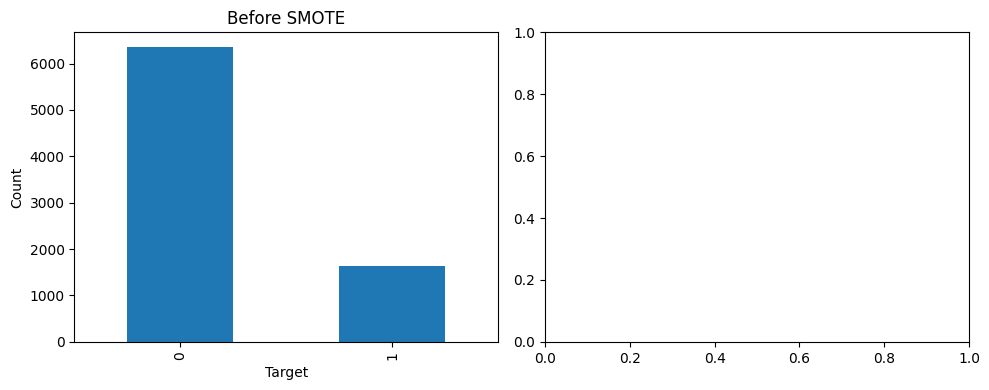

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Before
y_train.value_counts().sort_index().plot(kind='bar', ax=ax[0], title='Before SMOTE')
ax[0].set_ylabel('Count')

plt.tight_layout()
plt.show()

TREATING IMBALANCE USING SMOTE

In [59]:
# 1. IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    f1_score
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# 3. SPLIT FIRST — keep test set REALISTIC (imbalanced)
print("Step 1: Splitting data (preserving original imbalance in test set)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,        # ensures train/test have same % of class 1
    random_state=42
)

print("Original training set distribution:")
print(y_train.value_counts().sort_index())
print("\nOriginal test set distribution:")
print(y_test.value_counts().sort_index())


Step 1: Splitting data (preserving original imbalance in test set)...
Original training set distribution:
Target
0    6370
1    1630
Name: count, dtype: int64

Original test set distribution:
Target
0    1593
1     407
Name: count, dtype: int64


In [60]:
# 4. APPLY SMOTE ONLY TO TRAINING DATA
print("\n Step 2: Applying SMOTE to training data only...") 
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("After SMOTE — training set distribution:")
print(y_train_balanced.value_counts().sort_index())
# Now the training set is balanced while the test set remains imbalanced (realistic)



 Step 2: Applying SMOTE to training data only...
After SMOTE — training set distribution:
Target
0    6370
1    6370
Name: count, dtype: int64


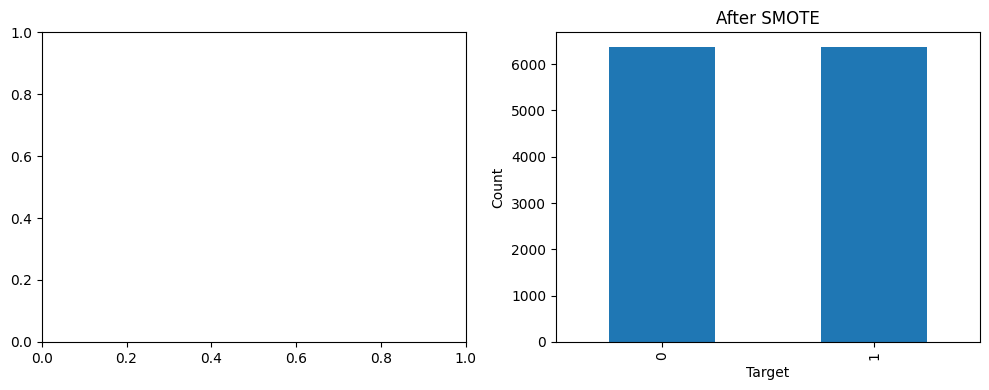

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))


# After
y_train_balanced.value_counts().sort_index().plot(kind='bar', ax=ax[1], title='After SMOTE')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**TRAINING THE MODEL BY USING RandomForestClassifier**

In [62]:
# Option A: Random Forest (no scaling needed)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit on balanced data
model.fit(X_train_balanced, y_train_balanced)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
#Now the training data is balanced (i.e., 6370 vs 6370)

# 5. TRAIN YOUR MODEL on BALANCED data
print("\n Step 3: Training model on balanced training data...")
# Choose one model — or try both!

# 6. EVALUATE ON ORIGINAL (IMBALANCED) TEST SET
print("\n Step 4: Evaluating on REALISTIC (imbalanced) test set...")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (churn)
# Key metrics for imbalanced data
print("\n✅ Classification Report (focus on Class 1 = Churn):")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

print("\n✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


 Step 3: Training model on balanced training data...

 Step 4: Evaluating on REALISTIC (imbalanced) test set...

✅ Classification Report (focus on Class 1 = Churn):
              precision    recall  f1-score   support

   Non-Churn       0.89      0.93      0.91      1593
       Churn       0.67      0.53      0.59       407

    accuracy                           0.85      2000
   macro avg       0.78      0.73      0.75      2000
weighted avg       0.84      0.85      0.84      2000


✅ Confusion Matrix:
[[1489  104]
 [ 193  214]]


In [64]:
# PR-AUC (better than ROC-AUC for imbalance)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\n Test Set PR-AUC: {pr_auc:.4f}")
print(f" Test Set F1-Score (Churn): {f1_score(y_test, y_pred):.4f}")


 Test Set PR-AUC: 0.6728
 Test Set F1-Score (Churn): 0.5903


Now let's apply Hyperparameter Tuning

In [65]:
# 5. IMPORT ADDITIONAL MODULES FOR TUNING
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint
from imblearn.pipeline import Pipeline as ImbPipeline  # Optional but cleaner
import joblib

#  Important: We'll tune on (X_train_balanced, y_train_balanced)
# But note: since data is now balanced, standard CV is fine

# 6. DEFINE MODEL & HYPERPARAMETER SPACE (Random Forest Example)
print("\n Step 3: Setting up hyperparameter tuning...")

# Option: Use a simple pipeline (not strictly needed for RF, but clean)
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Fast, smart hyperparameter grid
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt', 'log2']
}

# Use 3-fold CV (data is balanced now, so StratifiedKFold ≈ KFold)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search (faster than GridSearch)
search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',        # Still optimize F1 (even though train is balanced, test isn't!)
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 7. RUN TUNING ON BALANCED TRAINING DATA
print("\n Starting hyperparameter tuning on SMOTE-balanced training data...")
search.fit(X_train_balanced, y_train_balanced)

print("\n Best parameters found:")
print(search.best_params_)
print(f" Best CV F1-score: {search.best_score_:.4f}")

# 8. EVALUATE BEST MODEL ON ORIGINAL (IMBALANCED) TEST SET
print("\n Step 4: Evaluating best model on REALISTIC test set...")
y_pred = search.predict(X_test)
y_proba = search.predict_proba(X_test)[:, 1]

# Metrics for imbalanced evaluation
print("\n Final Test Results (on original imbalanced data):")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\n Test PR-AUC: {pr_auc:.4f}")
print(f" Test F1-Score (Churn): {f1_score(y_test, y_pred):.4f}")

# 9. SAVE THE BEST MODEL
joblib.dump(search.best_estimator_, "best_rf_model_smote_tuned.pkl")
print("\n Best tuned model saved: 'best_rf_model_smote_tuned.pkl'")


 Step 3: Setting up hyperparameter tuning...

 Starting hyperparameter tuning on SMOTE-balanced training data...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best parameters found:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
 Best CV F1-score: 0.9058

 Step 4: Evaluating best model on REALISTIC test set...

 Final Test Results (on original imbalanced data):
              precision    recall  f1-score   support

   Non-Churn       0.89      0.94      0.91      1593
       Churn       0.68      0.53      0.60       407

    accuracy                           0.85      2000
   macro avg       0.78      0.73      0.75      2000
weighted avg       0.84      0.85      0.85      2000


 Confusion Matrix:
[[1493  100]
 [ 192  215]]

 Test PR-AUC: 0.6721
 Test F1-Score (Churn): 0.5956

 Best tuned model saved: 'best_rf_model_smote_tuned.pkl'



 Top 10 Most Important Features:
1. Age: 0.2142
2. Geography: 0.1705
3. Gender: 0.1619
4. NumOfProducts: 0.1099
5. Balance: 0.0951
6. EstimatedSalary: 0.0760
7. CreditScore: 0.0718
8. Tenure: 0.0569
9. IsActiveMember: 0.0312
10. HasCrCard: 0.0122


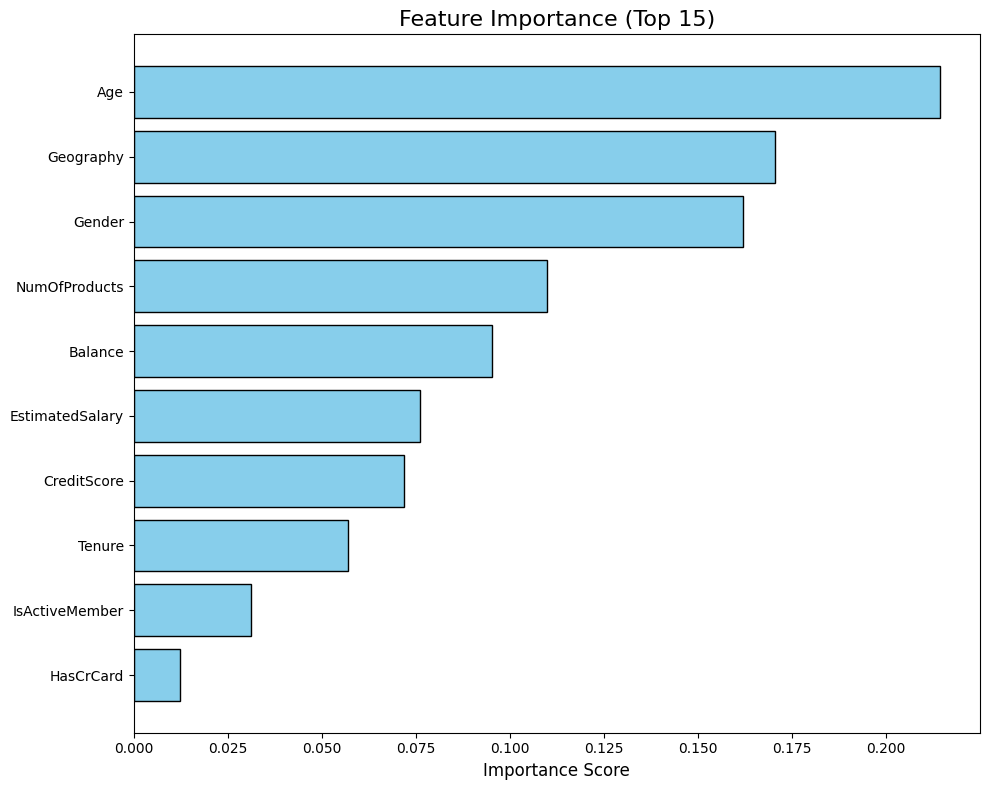

In [66]:
# 10. PLOT FEATURE IMPORTANCE
import matplotlib.pyplot as plt

# Get feature names (assuming X is a pandas DataFrame)
if isinstance(X, pd.DataFrame):
    feature_names = X.columns
else:
    # If X is a NumPy array, assign generic names
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Extract best model (tuned Random Forest)
best_model = search.best_estimator_

# Get feature importances
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]  # sort in descending order

# Print top 10 features
print("\n Top 10 Most Important Features:")
for i in range(min(10, len(importances))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_n = min(15, len(importances))
plt.title("Feature Importance (Top 15)", fontsize=16)
plt.barh(
    range(top_n),
    importances[indices[:top_n]],
    color='skyblue',
    edgecolor='black'
)
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.gca().invert_yaxis()  # Most important at top
plt.xlabel("Importance Score", fontsize=12)
plt.tight_layout()
plt.show()

**LET'S TRAIN THE MODEL BY USING LOGISTIC REGRESSION**

In [67]:
# 5. TRAIN YOUR MODEL on BALANCED data
print("\n Step 3: Training Logistic Regression on balanced training data...")

# Option B: Logistic Regression (requires scaling)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create a pipeline: scale features → train Logistic Regression
model = Pipeline([
    ('scaler', StandardScaler()),  # Critical for Logistic Regression!
    ('clf', LogisticRegression(
        random_state=42,
        max_iter=1000,          # Prevent convergence warnings
        class_weight=None       # Not needed — data is already balanced by SMOTE
    ))
])

# Fit on SMOTE-balanced training data
model.fit(X_train_balanced, y_train_balanced)




 Step 3: Training Logistic Regression on balanced training data...


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [68]:
# 6. EVALUATE ON ORIGINAL (IMBALANCED) TEST SET
print("\n Step 4: Evaluating on REALISTIC (imbalanced) test set...")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (churn)

# Key metrics for imbalanced data
print("\n Classification Report (focus on Class 1 = Churn):")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# PR-AUC (better than ROC-AUC for imbalance)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\n Test Set PR-AUC: {pr_auc:.4f}")
print(f" Test Set F1-Score (Churn): {f1_score(y_test, y_pred):.4f}")


 Step 4: Evaluating on REALISTIC (imbalanced) test set...

 Classification Report (focus on Class 1 = Churn):
              precision    recall  f1-score   support

   Non-Churn       0.90      0.73      0.80      1593
       Churn       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000


 Confusion Matrix:
[[1155  438]
 [ 123  284]]

 Test Set PR-AUC: 0.4985
 Test Set F1-Score (Churn): 0.5031


**APPLYING HYPERPARAMETER TUNING TO OUR LOGISTIC REGRESSION**

In [69]:
# 5. TRAIN YOUR MODEL on BALANCED data WITH HYPERPARAMETER TUNING
print("\n Step 3: Tuning Logistic Regression on balanced training data...")

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform
import numpy as np

# Build pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='saga'  # Required for l1, l2, and elasticnet
    ))
])

# Define hyperparameter search space
param_dist = {
    'clf__C': loguniform(0.01, 100),      # Regularization strength (log scale)
    'clf__penalty': ['l1', 'l2', 'elasticnet'],
    'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # Only used when penalty='elasticnet'
}

# Use 3-fold CV (faster; training data is balanced thanks to SMOTE)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search (Logistic Regression is fast → 30 iterations is great)
search = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',           # Optimize F1 — test set is imbalanced!
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# ✅ Fit on your SMOTE-balanced training data
search.fit(X_train_balanced, y_train_balanced)

# Use the best model for evaluation
model = search.best_estimator_

print(f"\n✅ Best parameters found:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"✅ Best CV F1-score: {search.best_score_:.4f}")

# 6. EVALUATE ON ORIGINAL (IMBALANCED) TEST SET
print("\n Step 4: Evaluating tuned Logistic Regression on REALISTIC test set...")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Metrics (reuse your existing imports)
print("\n✅ Classification Report (focus on Class 1 = Churn):")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

print("\n✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\n Test Set PR-AUC: {pr_auc:.4f}")
print(f" Test Set F1-Score (Churn): {f1_score(y_test, y_pred):.4f}")


 Step 3: Tuning Logistic Regression on balanced training data...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Best parameters found:
  clf__C: 0.010672476836323726
  clf__l1_ratio: 0.1
  clf__penalty: l1
✅ Best CV F1-score: 0.7174

 Step 4: Evaluating tuned Logistic Regression on REALISTIC test set...

✅ Classification Report (focus on Class 1 = Churn):
              precision    recall  f1-score   support

   Non-Churn       0.90      0.73      0.81      1593
       Churn       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.72      0.74      2000


✅ Confusion Matrix:
[[1158  435]
 [ 123  284]]

 Test Set PR-AUC: 0.4997
 Test Set F1-Score (Churn): 0.5044


**FEATURE IMPORTANCE**


🔍 Top 10 Features Influencing Churn (Logistic Regression):
           Feature  Coefficient
3              Age     0.851346
0        Geography     0.415472
8   IsActiveMember    -0.393434
1           Gender     0.240527
5          Balance     0.114529
6    NumOfProducts    -0.098592
9  EstimatedSalary     0.025969
2      CreditScore    -0.023742
4           Tenure     0.000000
7        HasCrCard     0.000000


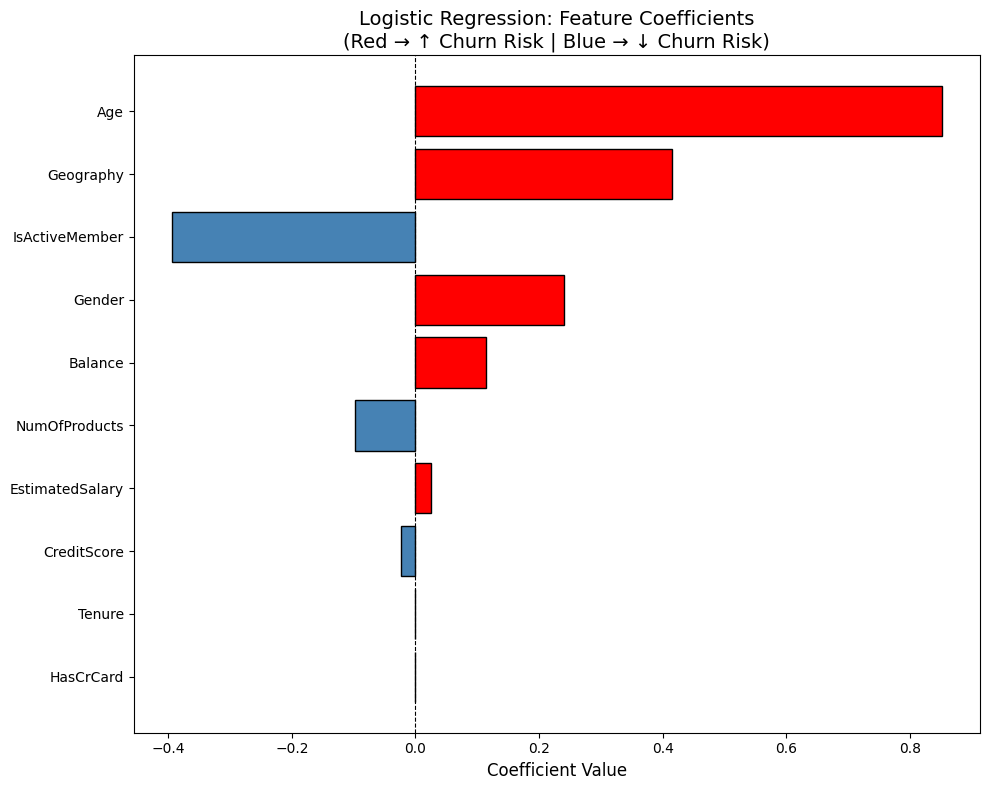

In [70]:

# 7. PLOT FEATURE COEFFICIENTS (Logistic Regression "Importance")
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature names (handle both DataFrame and array)
if isinstance(X, pd.DataFrame):
    feature_names = X.columns.tolist()
else:
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Extract coefficients from the trained Logistic Regression model
coef = model.named_steps['clf'].coef_[0]  # shape: (n_features,)

# Create a DataFrame for easy sorting and plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
})

# Sort by absolute value to show most influential features first
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

# Print top 10 features
print("\n🔍 Top 10 Features Influencing Churn (Logistic Regression):")
print(coef_df[['Feature', 'Coefficient']].head(10))

# Plot top 15 features
top_n = min(15, len(coef_df))
top_features = coef_df.head(top_n)

plt.figure(figsize=(10, 8))
colors = ['red' if x > 0 else 'steelblue' for x in top_features['Coefficient']]

plt.barh(
    top_features['Feature'],
    top_features['Coefficient'],
    color=colors,
    edgecolor='black'
)

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Coefficient Value", fontsize=12)
plt.title("Logistic Regression: Feature Coefficients\n(Red → ↑ Churn Risk | Blue → ↓ Churn Risk)", fontsize=14)
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()

**LET'S DECISION TREE CLASSIFIER WITH TUNING** 

In [71]:
# 5. TRAIN YOUR MODEL on BALANCED data
print("\n Step 3: Tuning DecisionTreeClassifier on balanced training data...")

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint
import numpy as np

# Base model
dt = DecisionTreeClassifier(
    random_state=42
)

# Hyperparameter space (focused on preventing overfitting)
param_dist = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 21),    # 2 to 20
    'min_samples_leaf': randint(1, 11),     # 1 to 10
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

# Use 3-fold CV (fast; data is balanced)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search
search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=40,
    cv=cv,
    scoring='f1',           # Optimize F1 — test set is imbalanced!
    n_jobs=-1,
    verbose=1,
    random_state=42
)

#  Fit on SMOTE-balanced training data
search.fit(X_train_balanced, y_train_balanced)

# Use best model
model = search.best_estimator_
model




 Step 3: Tuning DecisionTreeClassifier on balanced training data...
Fitting 3 folds for each of 40 candidates, totalling 120 fits


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,14
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [72]:
print(f"\n Best parameters: {search.best_params_}")
print(f" Best CV F1-score: {search.best_score_:.4f}")

# 6. EVALUATE ON ORIGINAL (IMBALANCED) TEST SET
print("\n Step 4: Evaluating Decision Tree on REALISTIC test set...")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (churn)

# Metrics
print("\n Classification Report (focus on Class 1 = Churn):")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\n Test Set PR-AUC: {pr_auc:.4f}")
print(f" Test Set F1-Score (Churn): {f1_score(y_test, y_pred):.4f}")


 Best parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 14}
 Best CV F1-score: 0.8521

 Step 4: Evaluating Decision Tree on REALISTIC test set...

 Classification Report (focus on Class 1 = Churn):
              precision    recall  f1-score   support

   Non-Churn       0.87      0.87      0.87      1593
       Churn       0.49      0.50      0.50       407

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.80      0.79      0.79      2000


 Confusion Matrix:
[[1384  209]
 [ 203  204]]

 Test Set PR-AUC: 0.5334
 Test Set F1-Score (Churn): 0.4976


**LET'S PLOT FEATURE IMPORTANCE**


🔍 Top 10 Important Features (Decision Tree):
1. Age: 0.2721
2. Geography: 0.1970
3. Gender: 0.1408
4. NumOfProducts: 0.1191
5. Balance: 0.0945
6. EstimatedSalary: 0.0581
7. CreditScore: 0.0402
8. IsActiveMember: 0.0383
9. Tenure: 0.0323
10. HasCrCard: 0.0076


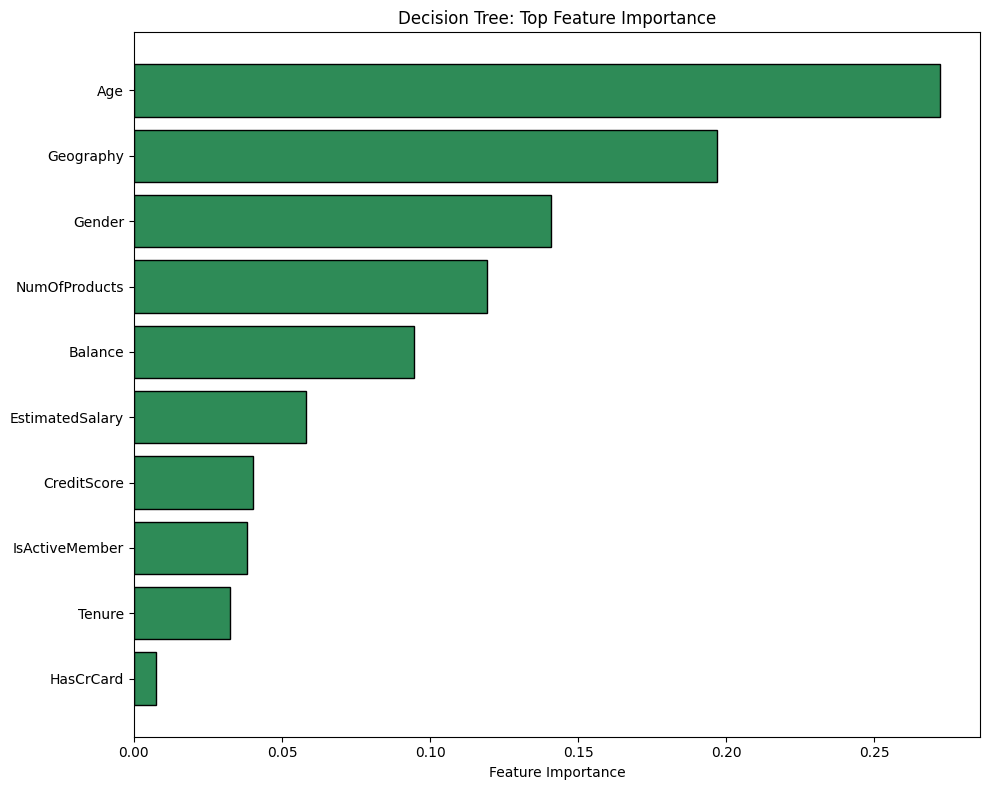

In [73]:
# 7. PLOT FEATURE IMPORTANCE
import matplotlib.pyplot as plt

# Get feature names
if isinstance(X, pd.DataFrame):
    feature_names = X.columns
else:
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Extract importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print top 10
print("\n🔍 Top 10 Important Features (Decision Tree):")
for i in range(min(10, len(importances))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Plot top 15
plt.figure(figsize=(10, 8))
top_n = min(15, len(importances))
plt.barh(
    range(top_n),
    importances[indices[:top_n]],
    color='seagreen',
    edgecolor='black'
)
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Decision Tree: Top Feature Importance")
plt.tight_layout()
plt.show()

In [74]:
import joblib
joblib.dump(model, "best_decision_tree_churn.pkl")
print("\n Best Decision Tree model saved!")


 Best Decision Tree model saved!


**LET'S TRAIN WITH SVM (SUPPORT VECTOR MACHINE) AND APPLY HYPERPARAMETER TUNING AT THE SAME TIME**

In [75]:
# 5. TRAIN YOUR MODEL on BALANCED data
print("\n Step 3: Tuning Support Vector Machine (SVM) on balanced training data...")

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, loguniform
import numpy as np

# Build pipeline: scale → SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # 🔑 Essential for SVM!
    ('svm', SVC(
        random_state=42,
        probability=True,   # Required for predict_proba() → needed for PR-AUC
        kernel='rbf'        # Most common; we'll tune gamma & C
    ))
])

# Hyperparameter space
param_dist = {
    'svm__C': loguniform(0.1, 1000),      # Regularization (wider range)
    'svm__gamma': loguniform(0.001, 1)    # Kernel coefficient
}

# Use 3-fold CV (SVM can be slow → keep folds low)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search
search = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=param_dist,
    n_iter=20,              # SVM is slow → fewer iterations
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# ✅ Fit on SMOTE-balanced training data
search.fit(X_train_balanced, y_train_balanced)

# Use best model
model = search.best_estimator_
model




 Step 3: Tuning Support Vector Machine (SVM) on balanced training data...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,np.float64(3.14891164795686)
,kernel,'rbf'
,degree,3
,gamma,np.float64(0.711447600934342)


In [76]:
print(f"\n✅ Best SVM parameters:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")
print(f"✅ Best CV F1-score: {search.best_score_:.4f}")


✅ Best SVM parameters:
  svm__C: 3.14891164795686
  svm__gamma: 0.711447600934342
✅ Best CV F1-score: 0.9028


In [77]:
# 6. EVALUATE ON ORIGINAL (IMBALANCED) TEST SET
print("\n Step 4: Evaluating SVM on REALISTIC test set...")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Enabled by probability=True

# Metrics
print("\n✅ Classification Report (focus on Class 1 = Churn):")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

print("\n✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\n Test Set PR-AUC: {pr_auc:.4f}")
print(f" Test Set F1-Score (Churn): {f1_score(y_test, y_pred):.4f}")


 Step 4: Evaluating SVM on REALISTIC test set...

✅ Classification Report (focus on Class 1 = Churn):
              precision    recall  f1-score   support

   Non-Churn       0.86      0.89      0.88      1593
       Churn       0.51      0.45      0.48       407

    accuracy                           0.80      2000
   macro avg       0.69      0.67      0.68      2000
weighted avg       0.79      0.80      0.80      2000


✅ Confusion Matrix:
[[1416  177]
 [ 223  184]]

 Test Set PR-AUC: 0.4593
 Test Set F1-Score (Churn): 0.4792


In [78]:
import joblib
joblib.dump(model, "best_svm_churn.pkl")
print("\n Best SVM model saved!")


 Best SVM model saved!


**LET'S TRAIN THE MODEL USING XGBOOST CLASSIFIER WITH HYPERPARAMETER TUNING**

In [79]:
# 5. TRAIN YOUR MODEL on BALANCED data
print("\n Step 3: Tuning XGBoost Classifier on balanced training data...")

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
import numpy as np

# Since your training data is balanced (6370 vs 6370), scale_pos_weight ≈ 1
# But we'll still include it for robustness (in case balance isn't perfect)
neg_count = y_train_balanced.value_counts().get(0, 0)
pos_count = y_train_balanced.value_counts().get(1, 0)
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"Using scale_pos_weight = {scale_pos_weight:.2f} (should be ~1.0)")

# Base XGBoost model
xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight  # Helps if slight imbalance remains
)

# Hyperparameter search space (fast and effective)
param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.19),  # 0.01 to 0.20
    'subsample': uniform(0.6, 0.4),        # 0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4), # 0.6 to 1.0
    'gamma': uniform(0, 5),                # min_split_loss
    'reg_alpha': uniform(0, 10),           # L1 regularization
    'reg_lambda': uniform(1, 10)           # L2 regularization
}

# Use 3-fold CV (fast; training data is balanced)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Randomized search
search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# ✅ Fit on SMOTE-balanced training data
search.fit(X_train_balanced, y_train_balanced)

# Use best model
model = search.best_estimator_
model


 Step 3: Tuning XGBoost Classifier on balanced training data...
Using scale_pos_weight = 1.00 (should be ~1.0)
Fitting 3 folds for each of 30 candidates, totalling 90 fits


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.878206434570451)
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [80]:
print(f"\n✅ Best XGBoost parameters:")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")
print(f"✅ Best CV F1-score: {search.best_score_:.4f}")


✅ Best XGBoost parameters:
  colsample_bytree: 0.878206434570451
  gamma: 0.6966572720293784
  learning_rate: 0.12483930206278528
  max_depth: 9
  n_estimators: 270
  reg_alpha: 2.030612247347694
  reg_lambda: 10.42853570557981
  subsample: 0.8395461865954144
✅ Best CV F1-score: 0.9014


In [81]:
# 6. EVALUATE ON ORIGINAL (IMBALANCED) TEST SET
print("\n Step 4: Evaluating XGBoost on REALISTIC test set...")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (churn)

# Metrics
print("\n Classification Report (focus on Class 1 = Churn):")
print(classification_report(y_test, y_pred, target_names=['Non-Churn', 'Churn']))

print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\n Test Set PR-AUC: {pr_auc:.4f}")
print(f" Test Set F1-Score (Churn): {f1_score(y_test, y_pred):.4f}")


 Step 4: Evaluating XGBoost on REALISTIC test set...

 Classification Report (focus on Class 1 = Churn):
              precision    recall  f1-score   support

   Non-Churn       0.88      0.94      0.91      1593
       Churn       0.67      0.51      0.58       407

    accuracy                           0.85      2000
   macro avg       0.78      0.72      0.75      2000
weighted avg       0.84      0.85      0.84      2000


 Confusion Matrix:
[[1491  102]
 [ 198  209]]

 Test Set PR-AUC: 0.6882
 Test Set F1-Score (Churn): 0.5822



🔍 Top 10 Important Features (XGBoost):
1. NumOfProducts: 0.2933
2. IsActiveMember: 0.1693
3. Gender: 0.1462
4. Age: 0.1424
5. Geography: 0.1152
6. Balance: 0.0457
7. Tenure: 0.0256
8. HasCrCard: 0.0217
9. CreditScore: 0.0203
10. EstimatedSalary: 0.0203


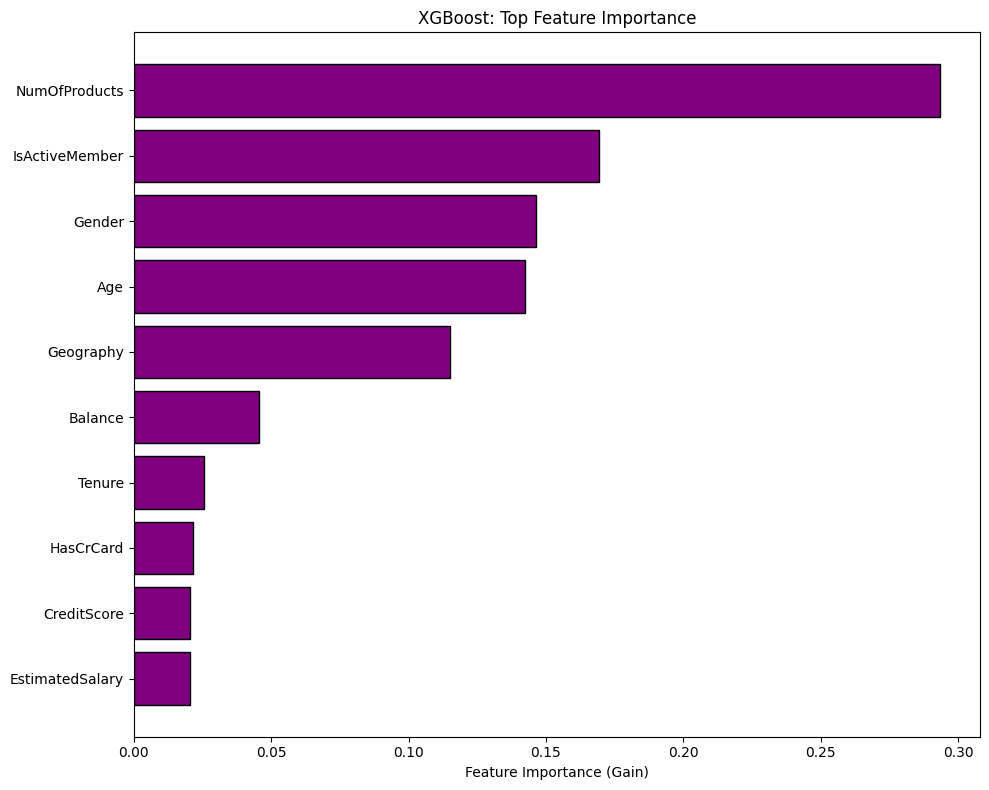

In [82]:
# 7. PLOT FEATURE IMPORTANCE
import matplotlib.pyplot as plt

# Get feature names
if isinstance(X, pd.DataFrame):
    feature_names = X.columns
else:
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

# Get importance (default: 'weight' — can also use 'gain', 'cover')
importance_scores = model.feature_importances_
indices = np.argsort(importance_scores)[::-1]

# Print top 10
print("\n🔍 Top 10 Important Features (XGBoost):")
for i in range(min(10, len(importance_scores))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importance_scores[indices[i]]:.4f}")

# Plot top 15
plt.figure(figsize=(10, 8))
top_n = min(15, len(importance_scores))
plt.barh(
    range(top_n),
    importance_scores[indices[:top_n]],
    color='purple',
    edgecolor='black'
)
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance (Gain)")
plt.title("XGBoost: Top Feature Importance")
plt.tight_layout()
plt.show()

In [83]:
import joblib
joblib.dump(model, "best_xgboost_churn.pkl")
print("\n Best XGBoost model saved!")


 Best XGBoost model saved!
